# Temas Tratados en el Trabajo Práctico 6

* Modelado de problemas en espacios de estado.

* Algoritmos de planificación hacia adelante y hacia atrás.

* Representación y solución de problemas descritos en lenguaje STRIPS.

* Algoritmo GRAPHPLAN.

* Planificación con restricciones de tiempo y recursos.

* Caminos críticos y tiempos de relajación.

## Ejercicios Teóricos

1. ¿En qué tipo de algoritmos se basa un planificador para encontrar el mejor camino a un estado solución?


2. ¿Qué tres elementos se encuentran dentro de una acción formulada en lenguaje STRIPS? Describa brevemente qué función cumple cada uno.

3. Describa las ventajas y desventajas de desarrollar un algoritmo de planificación hacia adelante y hacia atrás en el espacio de estados.


4. Considere el problema de ponerse uno mismo zapatos y medias. Aplique GRAPHPLAN a este problema y muestre la solución obtenida. Muestre el plan de orden parcial que es solución e indique cuántas linealizaciones diferentes existen para el plan de orden parcial.

5. Se requiere ensamblar una máquina cuyas piezas están identificadas con las letras A, B, C, D y E. El tiempo que se tarda en ensamblar cada pieza es:

* A: 2 semanas

* B: 1 semana

* C: 4 semanas

* D: 3 semanas

* E: 5 semanas

    El orden de ensamblaje de cada pieza requiere que:

* A esté realizado antes que C

* B esté realizado antes que C

* B esté realizado antes que D

* C esté realizado antes que E

* D esté realizado antes que E

    Con esta información:

        5.1 Arme el Plan de Orden Parcial.

        5.2 Encuentre el Camino Crítico.

        5.3 Encuentre los tiempos de relajación.

        5.4 Dibuje un diagrama temporal indicando las tareas y los tiempos de relajación encontrados.

**5.1)**   
El plan de orden parcial establece cómo fluye el proyecto desde su inicio hasta su fin.  
* El proyecto comienza con las tareas A y B en paralelo.

* La tarea C requiere que tanto A como B estén terminadas.

* La tarea D requiere solo que B esté terminada.

* La tarea E requiere que tanto C como D estén terminadas.  
Entonces:  
* Inicio $\rightarrow$ A $\rightarrow$ C $\rightarrow$ E $\rightarrow$ Fin  
* Inicio $\rightarrow$ B $\rightarrow$ C $\rightarrow$ E $\rightarrow$ Fin  
* Inicio $\rightarrow$ B $\rightarrow$ D $\rightarrow$ E $\rightarrow$ Fin  

**5.2)**  
Para encontrar el camino crítico, tenemos que calcular los tiempos de ida y los tiempos de vuelta para cada tarea.
1. Tiempos de ida: Buscamos el inicio temprano (ES) y el fin temprano (EF=ES+duración).  
* Tarea A: empieza en la semana 0, $$ES_A=0$$ entonces $$EF_A=0+2=2$$
* Tarea B: empieza en la semana 0, $$ES_B=0$$ entonces $$EF_B=0+1=1$$
* Tarea C: esta depende de A y B, su inicio temprano es cuando terminan ambas tareas, como A termina en dos semanas y B en una semana el inicio temprano de C es $$ES_C=2$$ entonces $$EF_C=2+4=6$$
* Tarea D: esta tarea depende de que B este terminada por lo tanto $$ES_D=1$$ entonces $$EF_D=1+3=4$$
* Tarea E: depende de que C y D esten termiandas entonces $$ES_E$$ máximo tiempo que tarda C y D esto es $$ES_E=6$$ entonces $$EF_E=6+5=11$$  
Por lo tanto el proyecto dura 11 semanas  
2. Tiempos de vuelta: Buscamos el fin tardío (LF) y el inicio tardío (LS=LF-duración) sin retrasar el proyecto.  
* Tarea E: Este termina en la semana 11 entonces $$LF_E=11$$ y $$LS_E=11-5=5$$
* Tarea C: Si E terminó significa que C también se realizó por lo tanto $$LF_C=LS_E=6$$ y $$LS_D=6-4=2$$
* Tarea D: de la misma manera que C tenemos que $$LF_D=LS_E=6$$ entonces $$LS_D=6-3=3$$
* Tarea A: Si C terminó es porque A se realizó entonces $$LF_A=LS_C=2$$ y $$LS_A=2-2=0$$
* Tarea B: de esta depende C y D, entonces $$LF_B$$ va a ser el mínimo tiempo entonces $$LF_B=2$$ y $$LS_B=2-1$$  

El Camino Crítico es la secuencia de tareas que no pueden retrasarse. Corresponde a las tareas donde el Inicio Temprano y el Inicio Tardío son iguales.  
Camino Crítico: A $\rightarrow$ C $\rightarrow$ E (Ruta: 2 + 4 + 5 = 11 semanas).  

**5.3)**
Para los tiempos de relajación tenemos que observar cuales de los procesos no afecta que se retasen y cuanto es el tiempo que pueden retrasarse para no afectar el proceso. Esto lo vemos comparando los tiempos de ida y los tiempos de vuelta, para A, C y E los tiempos de relajación son cero, esto significa que estos procesos no se pueden retrasar, pero para B y D los tiempos de relajación son $$TR_B=1 semana$$ y $$TR_D=2 semanas$$

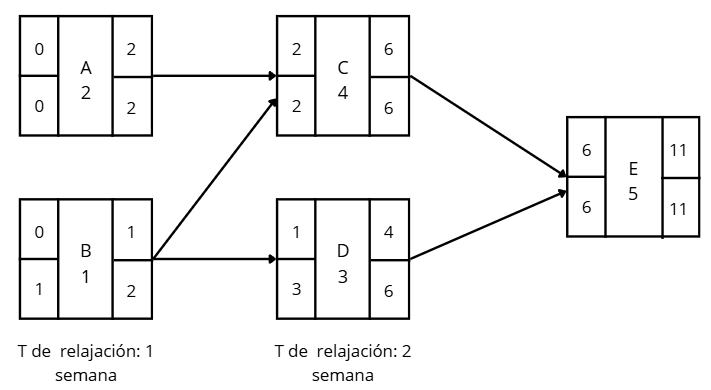

In [1]:
from IPython.display import Image, display

# Para mostrar una imagen guardada en tu computadora
display(Image(filename=r'C:\Users\merce\OneDrive\Imágenes\Screenshots\punto5.png'))

**5.4)**

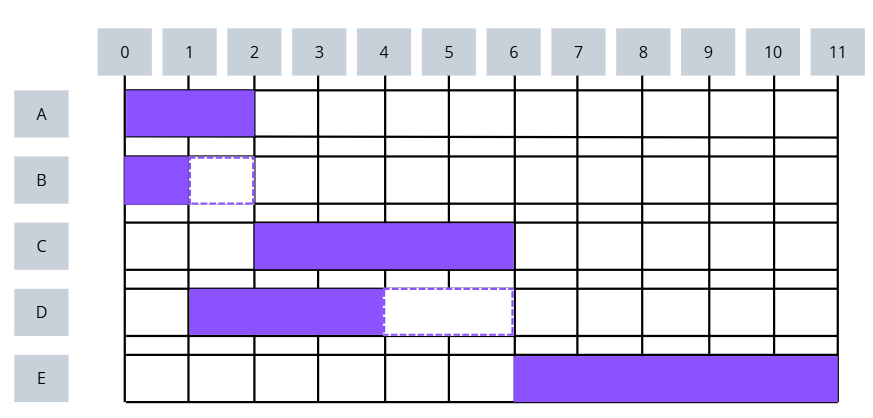

In [2]:
from IPython.display import Image, display

# Para mostrar una imagen guardada en tu computadora
display(Image(filename=r'C:\Users\merce\OneDrive\Imágenes\Screenshots\PUNTOMAPA.png'))

## Ejercicios de Implementación

> Recuerde adjuntar en la presentación el prompt inicial que ha utilizado para cada ejercicio de implementación y si considera que le dio la información completa para resolver el ejercicio o qué cambios adicionales tuvo que pedir de manera iterativa.

6. Suponga que tiene un robot de oficina capaz de moverse y tomar y depositar objetos. El robot solo puede tener un objeto a la vez, pero puede conseguir una *caja* en la que depositar varios objetos. Suponga que programa al robot para *ir a la tienda* a comprarle un *café* y en el camino de vuelta tome una *carta* del *buzón* de la oficina para para que se la traiga junto con el café. Describa en lenguaje STRIPS:

        6.1 El dominio del robot (nombre, predicados y acciones que puede hacer el robot).

        6.2 El problema que se quiere resolver (estado inicial, estado objetivo y objetos del mundo representados).

        6.3 Introduzca el código desarrollado en los puntos anteriores en el [planificador online](http://lcas.lincoln.ac.uk/fast-downward/) y obtenga el plan de acción que tomará el robot para cumplir lo solicitado.


# Bibliografía

[Russell, S. & Norvig, P. (2004) _Inteligencia Artificial: Un Enfoque Moderno_. Pearson Educación S.A. (2a Ed.) Madrid, España](https://www.academia.edu/8241613/Inteligencia_Aritificial_Un_Enfoque_Moderno_2da_Edici%C3%B3n_Stuart_J_Russell_y_Peter_Norvig)

[Poole, D. & Mackworth, A. (2023) _Artificial Intelligence: Foundations of Computational Agents_. Cambridge University Press (3a Ed.) Vancouver, Canada](https://artint.info/3e/html/ArtInt3e.html)